In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Read only the columns we need
USE_COLS = ["# Timestamp","MMSI","Latitude","Longitude","SOG","COG","Heading","Navigational status","Name","Ship type"]

# Robust path: works regardless of notebook working directory
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path.cwd()
DATA_PATH = NOTEBOOK_DIR / ".." / "data" / "aisdk-2025-03-01.csv"
DATA_PATH = DATA_PATH.resolve()
assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, usecols=lambda c: c in USE_COLS)
df["# Timestamp"] = pd.to_datetime(df["# Timestamp"], errors="coerce")

# Quick check: timestamps parsed correctly
print("Timestamp parsing successful:")
df[["# Timestamp"]].head(5)

### Data Types Check

In [50]:
# Check data types and sample data
print(df.dtypes)
df.head()

# Timestamp            datetime64[us]
MMSI                            int64
Latitude                      float64
Longitude                     float64
Navigational status               str
SOG                           float64
COG                           float64
Heading                       float64
Name                              str
Ship type                         str
dtype: object


,# Timestamp,MMSI,Latitude,Longitude,Navigational status,SOG,COG,Heading,Name,Ship type
0,2025-01-03,273257120,57.336578,8.189392,Under way using engine,10.9,236.8,238.0,NaN,Undefined
1,2025-01-03,219000431,54.524650,11.239300,Under way using engine,17.4,178.3,179.0,NaN,Undefined
2,2025-01-03,231336000,54.783100,10.353542,Under way using engine,9.2,127.2,124.0,NaN,Undefined
3,2025-01-03,352002621,56.828723,11.867325,Under way using engine,14.4,339.2,339.0,NaN,Undefined
4,2025-01-03,273257120,57.336578,8.189392,Under way using engine,10.9,236.8,238.0,NaN,Undefined


### Dataset Overview

Checking what's in this AIS dataset - how many vessels, time period, and data quality.

In [ ]:
n_rows = len(df)
n_vessels = df["MMSI"].nunique()
time_min, time_max = df["# Timestamp"].min(), df["# Timestamp"].max()

# (0,0) is the standard AIS placeholder for "no GPS fix"
# We check both lat AND lon == 0 together, not separately
# (latitude 0 alone is valid — it's the equator)
invalid_coords = (df["Latitude"] == 0) & (df["Longitude"] == 0)
pos_invalid = invalid_coords.mean()
sog_missing = df["SOG"].isna().mean()

pd.DataFrame({
    "rows":[n_rows],
    "unique_vessels":[n_vessels],
    "time_min":[time_min],
    "time_max":[time_max],
    "invalid_(0,0)_frac":[pos_invalid],
    "SOG_missing_frac":[sog_missing],
})

,rows,unique_vessels,time_min,time_max,invalid_position_frac,SOG_missing_frac
0,18977895,3685,2025-01-03,2025-01-03 23:59:58,0.005713,0.077783


### Select a vessel for analysis

I need to pick one vessel to analyze. I'll filter out (0,0) coordinates — the standard AIS placeholder meaning "no GPS fix" — and choose a vessel with lots of data points.

In [ ]:
# Remove only true (0,0) placeholders — both lat AND lon must be zero
df_valid = df[~((df["Latitude"] == 0) & (df["Longitude"] == 0))].copy()

moving_counts = df_valid[df_valid["SOG"].notna()]["MMSI"].value_counts()
moving_counts.head(10)


MMSI
219313000    59279
244238000    54525
257339000    50372
211190000    48546
246100000    47412
219022903    46836
219006092    46353
636018620    46340
219017895    45367
245097000    44572
Name: count, dtype: int64

In [55]:
# Select vessel with most AIS messages and extract its data
SELECTED_MMSI = int(moving_counts.index[0])  # change if you want another vessel

vessel = df_valid[df_valid["MMSI"] == SELECTED_MMSI].copy()
vessel = vessel.sort_values("# Timestamp").reset_index(drop=True)
vessel = vessel[vessel["SOG"].notna()].copy()  # keep only rows with SOG

print(f"Selected MMSI: {SELECTED_MMSI}")
print(f"Number of AIS messages: {len(vessel)}")

Selected MMSI: 219313000
Number of AIS messages: 59279


### Vessel Selection Strategy

From all the vessels in the dataset, I need to pick one for detailed analysis. Here's my selection logic:

**Why be picky?**
- Some vessels have very few AIS messages (not interesting)
- Some vessels never move (always at dock)
- Some have bad GPS data (lots of missing speeds)

**My filtering process:**
1. **Remove (0,0) placeholders**: AIS uses (0,0) to mean "no GPS fix" — we drop only those, not legitimate equatorial positions
2. **Find active vessels**: Count vessels that have speed data
3. **Pick the busiest**: Choose vessel with most AIS messages
4. **Clean the data**: Keep only messages that have speed information

**Result**: I get a vessel that was actually moving around during the data period, with good quality AIS data for analysis.

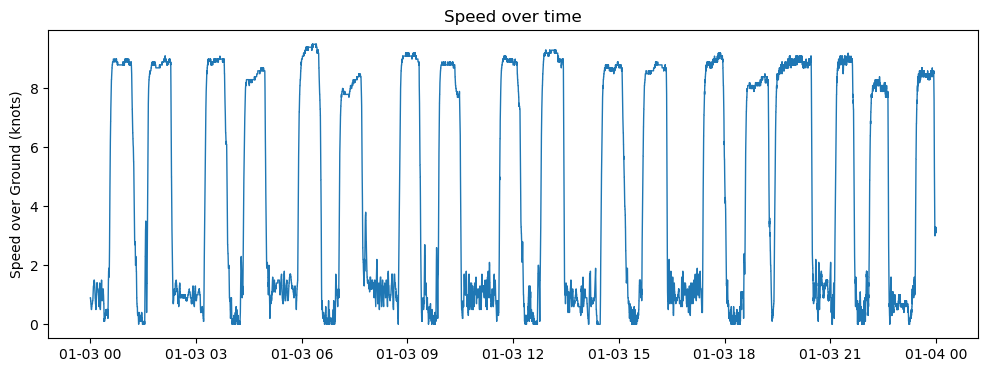

In [56]:
# Speed profile
plt.figure(figsize=(12, 4))
plt.plot(vessel["# Timestamp"], vessel["SOG"], linewidth=1)
plt.ylabel("Speed over Ground (knots)")
plt.title("Speed over time")
plt.show()


### Analyze vessel movement

Now let me look at how the vessel moves - speed over time and distances between AIS messages.

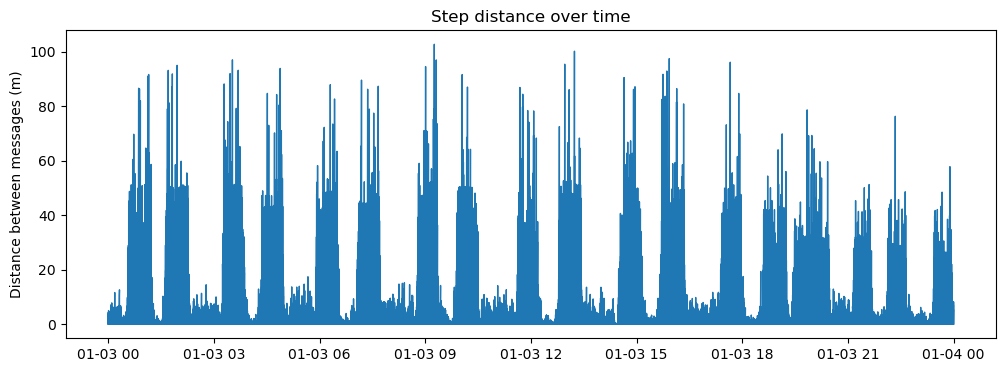

In [57]:
from geopy.distance import geodesic

# Distance between consecutive AIS points (meters) using geopy
def calculate_distance(row):
    if pd.isna(row['prev_lat']) or pd.isna(row['prev_lon']):
        return 0.0
    return geodesic((row['prev_lat'], row['prev_lon']), (row['Latitude'], row['Longitude'])).meters

vessel["dt_min"] = vessel["# Timestamp"].diff().dt.total_seconds() / 60

# Shift coordinates to get previous point
vessel['prev_lat'] = vessel['Latitude'].shift()
vessel['prev_lon'] = vessel['Longitude'].shift()

# Apply distance calculation
vessel["distance_m"] = vessel.apply(calculate_distance, axis=1)

# Drop temporary columns
vessel = vessel.drop(columns=['prev_lat', 'prev_lon'])

plt.figure(figsize=(12, 4))
plt.plot(vessel["# Timestamp"], vessel["distance_m"], linewidth=1)
plt.ylabel("Distance between messages (m)")
plt.title("Step distance over time")
plt.show()


### Distance Calculation Method

I need to calculate how far the vessel moved between each AIS message.


**My approach:**
1. Use `geopy.distance.geodesic()`
2. Calculate distance from each point to the previous point  
3. Also calculate time differences between messages
4. Plot both distance and time to understand movement patterns

**What the plots show:**
- **Speed plot**: Shows when vessel was fast vs slow vs stopped
- **Distance plot**: Shows big jumps (fast movement) vs small steps (slow/stopped)

### Journey segmentation

I want to identify different parts of the vessel's movement:
- **Stop**: When speed is very low (< 1 knot)  
- **Moving**: When speed is higher
- **Journey**: Longer trips with good speed

This will help group the AIS messages by the vessel's behavior.

In [ ]:
# Simple thresholds
STOP_SPEED = 1.0    # knots
JOURNEY_SPEED = 3.0 # knots
GAP_TIME = 30       # minutes

# Smooth SOG with rolling average to reduce noise-induced state flipping
# AIS low-speed readings can bounce around 0-2 knots; smoothing stabilises this
vessel["SOG_smooth"] = vessel["SOG"].rolling(window=5, min_periods=1).mean()

# Classify vessel states using smoothed speed
vessel["state"] = "moving"
vessel.loc[vessel["SOG_smooth"] < STOP_SPEED, "state"] = "stop"
vessel.loc[vessel["dt_min"] > GAP_TIME, "state"] = "gap"

# Create segment IDs
vessel["segment_id"] = (vessel["state"] != vessel["state"].shift()).cumsum()

# Find journeys (high speed segments)
segment_stats = vessel.groupby("segment_id").agg({
    "state": "first",
    "SOG": "mean",
    "# Timestamp": ["min", "max"]
})

segment_stats.columns = ["state", "avg_speed", "start_time", "end_time"]
segment_stats["duration_min"] = (segment_stats["end_time"] - segment_stats["start_time"]).dt.total_seconds() / 60

# Assign journey IDs to fast segments
journeys = segment_stats[
    (segment_stats["state"] == "moving") & 
    (segment_stats["avg_speed"] >= JOURNEY_SPEED) &
    (segment_stats["duration_min"] >= 10)
].index

journey_map = {seg_id: i+1 for i, seg_id in enumerate(journeys)}
vessel["journey_id"] = vessel["segment_id"].map(journey_map)

# Ensure journey_id only applies to moving states (not leaked to gaps/stops)
vessel["journey_id"] = np.where(vessel["state"] == "moving", vessel["journey_id"], np.nan)

print(f"Found {len(journeys)} journeys")
vessel["state"].value_counts()

Found 18 journeys


state
moving    44239
stop      15040
Name: count, dtype: int64

### Journey Segmentation Algorithm

This is where I classify each AIS message into different states based on vessel behavior:

**Step 1: Define Thresholds**
- `STOP_SPEED = 1.0 knots`: Below this = vessel is stopped or docking
- `JOURNEY_SPEED = 3.0 knots`: Above this = real journey (not just slow maneuvering)  
- `GAP_TIME = 30 minutes`: Missing AIS data (turned off or out of range)

**Step 2: Smooth Speed**
- Use a rolling 5-point average to reduce AIS low-speed noise
- Without smoothing, noisy readings around 1 knot cause many false stop↔moving transitions

**Step 3: Classify States** (using smoothed speed)
- Start with "moving" as default
- If smoothed speed < 1 knot → "stop"
- If time gap > 30 min → "gap"

**Step 4: Create Segments**
- Group consecutive messages with same state
- Each state change creates a new segment

**Step 5: Identify Journeys**
- Look at "moving" segments only
- Must have average speed ≥ 3 knots (real transit)
- Must last ≥ 10 minutes (not just brief speed-up)
- Give these segments journey IDs (1, 2, 3...)
- Journey ID is only assigned to "moving" rows (not leaked to stops/gaps)

In [59]:
# Show the journeys we found with detailed information
from geopy.distance import geodesic

journey_analysis = []
for journey_id in vessel["journey_id"].dropna().unique():
    journey_data = vessel[vessel["journey_id"] == journey_id].copy()
    
    # Calculate journey details
    start_time = journey_data["# Timestamp"].min()
    end_time = journey_data["# Timestamp"].max()
    duration_min = (end_time - start_time).total_seconds() / 60
    avg_speed = journey_data["SOG"].mean()
    max_speed = journey_data["SOG"].max()
    
    # Calculate total distance
    total_distance = 0
    for i in range(1, len(journey_data)):
        prev_point = (journey_data.iloc[i-1]["Latitude"], journey_data.iloc[i-1]["Longitude"])
        curr_point = (journey_data.iloc[i]["Latitude"], journey_data.iloc[i]["Longitude"])
        total_distance += geodesic(prev_point, curr_point).kilometers
    
    # Start and end locations
    start_lat = journey_data.iloc[0]["Latitude"]
    start_lon = journey_data.iloc[0]["Longitude"]
    end_lat = journey_data.iloc[-1]["Latitude"]
    end_lon = journey_data.iloc[-1]["Longitude"]
    
    journey_analysis.append({
        "Journey_ID": int(journey_id),
        "Start_Time": start_time,
        "End_Time": end_time,
        "Duration_min": round(duration_min, 1),
        "Distance_km": round(total_distance, 2),
        "Avg_Speed_kn": round(avg_speed, 1),
        "Max_Speed_kn": round(max_speed, 1),
        "Start_Lat": round(start_lat, 4),
        "Start_Lon": round(start_lon, 4),
        "End_Lat": round(end_lat, 4),
        "End_Lon": round(end_lon, 4)
    })

import pandas as pd
journey_df = pd.DataFrame(journey_analysis)
print(f"Found {len(journey_df)} distinct journeys:")
journey_df

Found 18 distinct journeys:


,Journey_ID,Start_Time,End_Time,Duration_min,Distance_km,Avg_Speed_kn,Max_Speed_kn,Start_Lat,Start_Lon,End_Lat,End_Lon
0,1,2025-01-03 00:30:23,2025-01-03 01:18:55,48.5,11.57,7.3,9.0,56.6681,8.0104,56.6941,8.1886
1,2,2025-01-03 01:36:07,2025-01-03 02:20:20,44.2,11.39,8.1,9.1,56.6948,8.1867,56.6689,8.0128
2,3,2025-01-03 03:13:30,2025-01-03 03:56:42,43.2,10.46,7.7,9.1,56.6823,8.0199,56.6942,8.1879
3,4,2025-01-03 04:18:35,2025-01-03 05:05:02,46.5,10.14,6.7,8.7,56.6950,8.1873,56.6870,8.0257
4,5,2025-01-03 05:51:29,2025-01-03 06:33:39,42.2,10.96,8.3,9.5,56.6726,8.0146,56.6941,8.1878
5,6,2025-01-03 07:02:55,2025-01-03 08:02:59,60.1,11.07,5.7,8.5,56.6952,8.1884,56.6822,8.0277
6,7,2025-01-03 08:44:42,2025-01-03 09:23:18,38.6,10.14,8.3,9.2,56.6807,8.0277,56.6942,8.1872
7,8,2025-01-03 09:52:00,2025-01-03 10:31:43,39.7,9.96,7.9,8.9,56.6948,8.1873,56.6804,8.0283
8,9,2025-01-03 11:35:59,2025-01-03 12:17:42,41.7,10.10,7.9,9.1,56.6804,8.0281,56.6945,8.1887
9,10,2025-01-03 12:45:42,2025-01-03 13:28:37,42.9,11.15,8.1,9.3,56.6945,8.1868,56.6759,8.0107


### Detailed Journey Analysis

Now I want to analyze each journey in detail. For each journey, I'll calculate:

1. **Time information**: When it started and ended, how long it took
2. **Distance calculation**: Using geopy to measure actual travel distance between GPS points
3. **Speed analysis**: Average and maximum speed during the journey
4. **Geographic boundaries**: Start and end coordinates

This will give me a complete picture of each vessel trip.

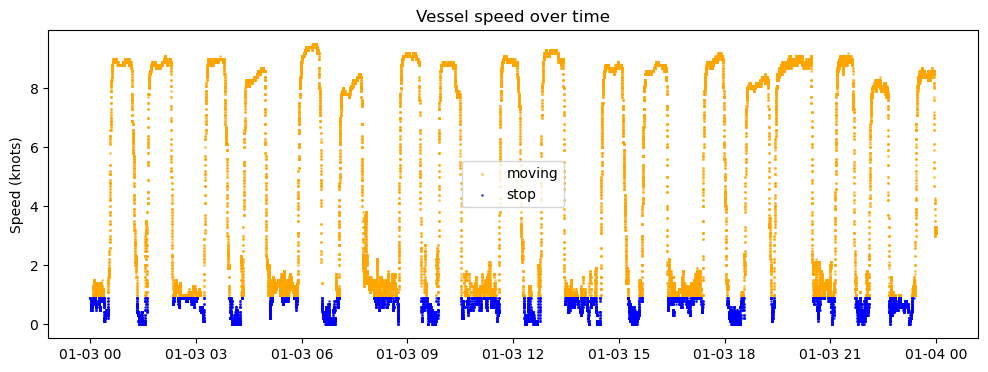

In [60]:
# Plot speed by state
plt.figure(figsize=(12, 4))

colors = {"moving": "orange", "stop": "blue", "gap": "red"}
for state, group in vessel.groupby("state"):
    plt.scatter(group["# Timestamp"], group["SOG"], c=colors[state], label=state, alpha=0.6, s=1)

plt.legend()
plt.ylabel("Speed (knots)")
plt.title("Vessel speed over time")
plt.show()

### Visualize the results

Plotting the speed data to see the different states (moving, stopped, gaps).

### Show vessel track on map

In [ ]:
import folium

# Create map centered on vessel area
center_lat = vessel["Latitude"].mean()
center_lon = vessel["Longitude"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=8)

# Add full vessel track as light background
track_points = list(zip(vessel["Latitude"], vessel["Longitude"]))
folium.PolyLine(
    track_points, 
    color="lightblue", 
    weight=1, 
    opacity=0.5,
    popup="Complete vessel track"
).add_to(m)

# Add journey paths with detailed labels
journey_colors = ["red", "green", "purple", "orange", "darkblue", "pink"]
for i, journey_id in enumerate(sorted(vessel["journey_id"].dropna().unique())):
    journey_data = vessel[vessel["journey_id"] == journey_id]
    journey_track = list(zip(journey_data["Latitude"], journey_data["Longitude"]))
    color = journey_colors[i % len(journey_colors)]
    
    # Get journey details for popup
    duration = (journey_data["# Timestamp"].max() - journey_data["# Timestamp"].min()).total_seconds() / 60
    avg_speed = journey_data["SOG"].mean()
    
    # Add journey line
    folium.PolyLine(
        journey_track, 
        color=color, 
        weight=4,
        popup=f"Journey {int(journey_id)}: {duration:.0f} min, {avg_speed:.1f} knots avg"
    ).add_to(m)
    
    # Add start marker
    start_point = journey_track[0]
    folium.Marker(
        start_point,
        popup=f"Journey {int(journey_id)} START<br>{journey_data.iloc[0]['# Timestamp'].strftime('%H:%M')}",
        tooltip=f"Start J{int(journey_id)}",
        icon=folium.Icon(color="green", icon="play")
    ).add_to(m)
    
    # Add end marker  
    end_point = journey_track[-1]
    folium.Marker(
        end_point,
        popup=f"Journey {int(journey_id)} END<br>{journey_data.iloc[-1]['# Timestamp'].strftime('%H:%M')}",
        tooltip=f"End J{int(journey_id)}",
        icon=folium.Icon(color="red", icon="stop")
    ).add_to(m)

# Add stop locations — group by actual time gaps, not row index
stops = vessel[vessel["state"] == "stop"].copy()
stops["time_gap"] = stops["# Timestamp"].diff().dt.total_seconds() / 60
stop_groups = stops.groupby((stops["time_gap"] > 5).cumsum())  # new stop if gap > 5 min

for group_id, stop_group in stop_groups:
    if len(stop_group) >= 3:  # Only show significant stops
        center_lat = stop_group["Latitude"].mean()
        center_lon = stop_group["Longitude"].mean()
        duration = (stop_group["# Timestamp"].max() - stop_group["# Timestamp"].min()).total_seconds() / 60
        
        # Size marker based on stop duration
        if duration > 60:  # > 1 hour
            radius = 8
            color = "darkred"
        elif duration > 20:  # > 20 min
            radius = 6  
            color = "red"
        else:
            radius = 4
            color = "orange"
            
        folium.CircleMarker(
            [center_lat, center_lon],
            radius=radius,
            color=color,
            fill=True,
            popup=f"Stop: {duration:.0f} minutes<br>From: {stop_group.iloc[0]['# Timestamp'].strftime('%H:%M')}<br>To: {stop_group.iloc[-1]['# Timestamp'].strftime('%H:%M')}",
            tooltip=f"Stop ({duration:.0f}min)"
        ).add_to(m)

# Add a legend
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 120px; 
     border:2px solid grey; z-index:9999; 
     font-size:14px; background-color:white">
<p style="margin: 8px;"><b>Vessel Track Legend</b></p>
<p style="margin: 8px;"><span style="color:lightblue;">━━━</span> Full track</p>
<p style="margin: 8px;"><span style="color:red;">━━━</span> Journeys (colored)</p>
<p style="margin: 8px;">🟢 Journey start</p>
<p style="margin: 8px;">🔴 Journey end</p>
<p style="margin: 8px;">🟠 Stop locations</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

print(f"Map shows {len(vessel['journey_id'].dropna().unique())} journeys and {len([g for _, g in stop_groups if len(g) >= 3])} major stops")
m.save('vessel_map.html')
print("Enhanced map saved as vessel_map.html")
m

Map shows 18 journeys and 121 major stops
Enhanced map saved as vessel_map.html


### Interactive Map Creation Logic

**Map Layers** (from bottom to top):
1. **Background track** (light blue): Complete vessel path as context
2. **Journey lines** (colored): Each journey in a different bright color
3. **Start markers** (green): Where each journey begins
4. **End markers** (red): Where each journey ends  
5. **Stop circles** (orange/red): Places where vessel stayed for a while

**Interactive Features**:
- **Popups**: Click on lines/markers to see details (time, speed, duration)
- **Tooltips**: Hover for quick information
- **Legend**: Explains what each color/symbol means

**Smart Filtering**:
- Only shows significant stops (≥3 AIS messages)
- Sizes stop markers by duration (longer stops = bigger circles)
- Groups nearby stop points together

The goal is to tell the story of where this vessel went and what it did.